# SECOM — exploratory data analysis

This is the first stop in the SECOM phase of the project. SECOM is a real dataset from a semiconductor manufacturer (donated to UCI in 2008): 1,567 production runs of finished wafers, with 590 sensor signals captured during each run and a pass/fail label from final electrical test.

Before doing any modeling, I wanted to answer four things about the data:

1. **How imbalanced is the target?** This decides whether accuracy is a useful metric (it usually isn't with rare positives).
2. **How bad is the missing-data problem?**
3. **Are there obvious junk features** — fully missing columns, constant sensors — I can drop without thinking?
4. **Is there any low-dimensional structure** I can see at the EDA stage that would tell me what kind of model to bias toward?

If the answers are "very imbalanced, fairly messy, yes there are junk features, no obvious linear separation" then we're in normal industrial-data territory and the rest of the project will play out as expected. Let me check.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_io import load_secom
from src.plots import missingness_heatmap

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

In [2]:
X, y, ts = load_secom("../data/raw/secom")
print(f"X: {X.shape}")
print(f"y: {y.shape}, pos rate = {y.mean():.3%}")
print(f"timestamps from {ts.min()} to {ts.max()}")
X.head()

X: (1567, 590)
y: (1567,), pos rate = 6.637%
timestamps from 2008-07-19 11:55:00 to 2008-10-17 06:07:00


,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_580,sensor_581,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589
0,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,1.5005,0.0162,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,1.4966,-0.0005,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,1.4436,0.0041,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,1.4882,-0.0124,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,1.5031,-0.0031,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


## 1. Class balance

104 fails out of 1,567 runs — about 6.6% positive class.

That's actually *higher* than I'd guess for a real fab. The yield numbers I've seen in papers and online are more in the 1–3% scrap range. SECOM has been anonymized and possibly downsampled, so I'm not going to read too much into the absolute rate.

What matters is that **accuracy is useless here**: a model that predicts "pass" for every wafer scores 93.4% accuracy and is completely worthless. From this point on I'll evaluate on PR-AUC, recall, and F1 instead — those actually measure how well the model picks out the rare positives.

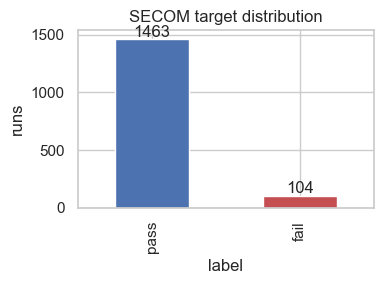

label
pass    1463
fail     104
Name: count, dtype: int64

In [3]:
counts = y.value_counts().rename({0: "pass", 1: "fail"})
fig, ax = plt.subplots(figsize=(4, 3))
counts.plot(kind="bar", color=["#4c72b0", "#c44e52"], ax=ax)
ax.set_title("SECOM target distribution")
ax.set_ylabel("runs")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center")
plt.tight_layout()
plt.show()
counts

## 2. Missing values

Around 4.5% of all sensor readings are missing — but it's not uniformly spread. The histogram below shows most sensors have <5% missing, and then there's a long tail of sensors missing 30%+ of the time, including a chunk that are >50% missing.

That's good to know up front: a single imputation strategy won't suit both groups. For the moderately-missing sensors, median imputation is fine. For the >50% missing ones, I'd rather drop them than make up most of the data.

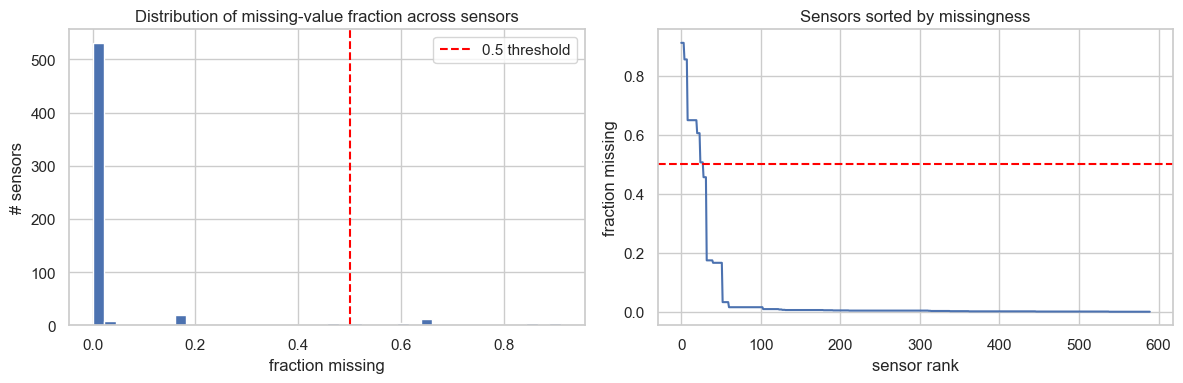

sensors with >50% missing: 28
sensors with any missing : 538


In [4]:
miss_frac = X.isna().mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(miss_frac.values, bins=40, color="#4c72b0", edgecolor="white")
axes[0].axvline(0.5, color="red", linestyle="--", label="0.5 threshold")
axes[0].set_title("Distribution of missing-value fraction across sensors")
axes[0].set_xlabel("fraction missing")
axes[0].set_ylabel("# sensors")
axes[0].legend()

axes[1].plot(np.arange(len(miss_frac)), miss_frac.values, color="#4c72b0")
axes[1].axhline(0.5, color="red", linestyle="--")
axes[1].set_title("Sensors sorted by missingness")
axes[1].set_xlabel("sensor rank")
axes[1].set_ylabel("fraction missing")

plt.tight_layout(); plt.show()

print(f"sensors with >50% missing: {(miss_frac > 0.5).sum()}")
print(f"sensors with any missing : {(miss_frac > 0).sum()}")

Plotting the top-100 sparsest sensors as a heatmap shows the missingness has **structure** — there are clear horizontal bands where multiple sensors went missing on the same rows.

If I'm reading this right, that's what you'd expect if a measurement tool went offline during a run: a bunch of related sensors all stopped reporting at the same time. Column-wise imputation will still work for most cells, but it won't be able to recover the rows where half the sensors dropped out together. Worth keeping in mind for the cleaning notebook.

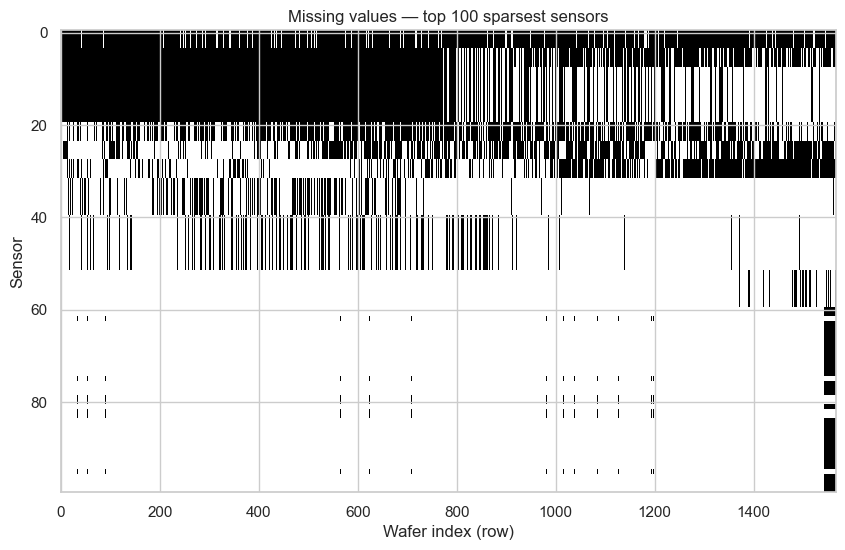

In [5]:
missingness_heatmap(X, top_n=100); plt.show()

## 3. Variance — how many sensors are dead weight?

Per-sensor variance on a log scale. Anything at the floor of this plot is a sensor that was on but never moved during these 1,567 runs — i.e. a constant feature, zero information for any kind of model.

This is one of the easiest free wins in tabular cleaning. I'll drop these in notebook 02 without a second thought.

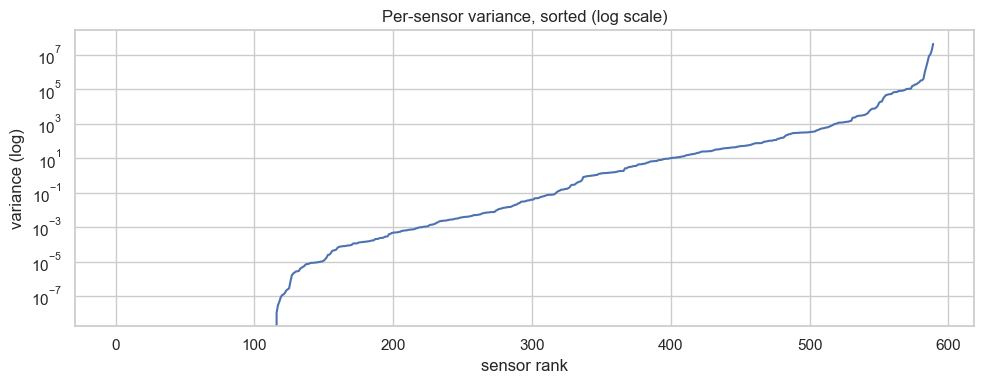

sensors with variance < 1e-12 (effectively constant): 116
sensors with variance == 0 exactly                  : 116


In [6]:
variances = X.var(numeric_only=True).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(variances.values, color="#4c72b0")
ax.set_title("Per-sensor variance, sorted (log scale)")
ax.set_xlabel("sensor rank")
ax.set_ylabel("variance (log)")
plt.tight_layout(); plt.show()

print(f"sensors with variance < 1e-12 (effectively constant): {(variances < 1e-12).sum()}")
print(f"sensors with variance == 0 exactly                  : {(variances == 0).sum()}")

Picking six non-constant sensors at random to see what individual sensor distributions look like.

Most are tight clusters with heavy tails (a few values way out in the wings). That's a useful observation for the scaling step: `StandardScaler` would compress the bulk of the distribution to almost nothing because the outliers would dominate. `RobustScaler` (median + IQR) handles this much better, so that's what I'll use later.

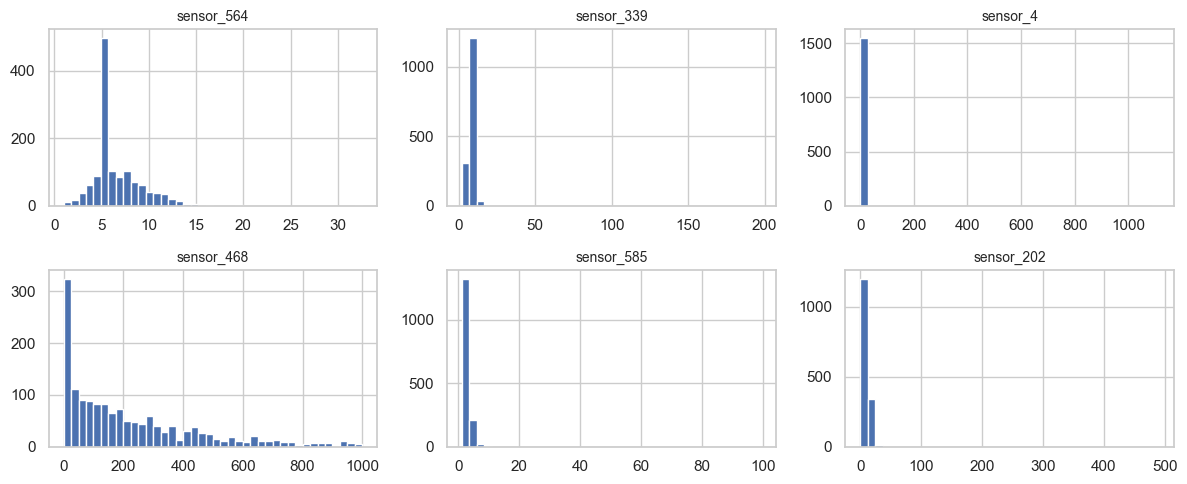

In [7]:
non_const_cols = variances[variances > 1e-12].index.tolist()
rng = np.random.default_rng(7)
sample = rng.choice(non_const_cols, size=6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for ax, col in zip(axes.flat, sample):
    ax.hist(X[col].dropna(), bins=40, color="#4c72b0", edgecolor="white")
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

## 4. Is there any low-dimensional structure?

If the failing wafers clustered cleanly in 2D, this would be an easy problem. They don't — and honestly, that's the more realistic outcome.

A quick PCA on a median-imputed version of the data (just for the visualization — the real pipeline does imputation properly in notebook 02) shows fails scattered throughout the pass cloud, with maybe a slight tilt to one side. Nothing close to clean separation.

What I take from this: **linear models are going to struggle here**. Whatever signal exists is probably hiding in interactions between many sensors rather than any single direction in feature space. That's an argument for a tree ensemble being the natural primary model for this dataset.

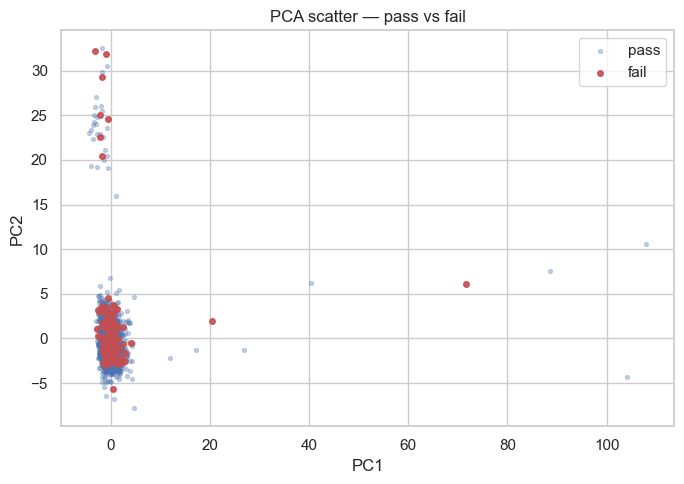

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_quick = X.fillna(X.median(numeric_only=True))
X_quick = X_quick.loc[:, X_quick.var() > 1e-12]
X_quick = StandardScaler().fit_transform(X_quick)

pcs = PCA(n_components=2, random_state=0).fit_transform(X_quick)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pcs[y == 0, 0], pcs[y == 0, 1], s=8, alpha=0.3, label="pass", color="#4c72b0")
ax.scatter(pcs[y == 1, 0], pcs[y == 1, 1], s=16, alpha=0.9, label="fail", color="#c44e52")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA scatter — pass vs fail")
ax.legend()
plt.tight_layout(); plt.show()

## What this tells me for the next notebook

Tally for the cleaning pipeline I'll build in notebook 02:

- **Imbalance** (~6.6% fail) → primary metric is PR-AUC, with recall as the operating constraint. SMOTE on the training set is worth trying.
- **Missing values** → drop columns with >50% missing, then median-impute the rest. (I considered KNN imputation but with 590 features and a tight train set it's slow and not obviously better.)
- **Constant / near-constant sensors** → drop. Probably 100+ columns gone immediately.
- **Heavy tails** → `RobustScaler` rather than `StandardScaler`.
- **High correlation** → I'd expect lots of redundant sensors. Drop one of each pair with |r| > 0.95 after imputation.
- **No obvious linear separability** → tree ensembles will probably win. Logistic regression is still useful as a baseline. A small MLP is worth trying but I'm not optimistic given the data size.

On to notebook 02.